# SILVA Efficient Infinite-Depth Graph Equilibrium

This lab derives the EIGNN spectral solution, verifies it against the iterative
SILVA route, checks gradients, and explains when a sparse solve is required.
The defining mechanism follows EIGNN [[78]](https://jseluis.github.io/silva-networks/paper/references/#ref-78).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[78]](https://jseluis.github.io/silva-networks/paper/references/#ref-78), [[82]](https://jseluis.github.io/silva-networks/paper/references/#ref-82). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

from silva_networks import (
    SILVAEfficientInfiniteGraphEquilibrium,
    SolverConfig,
    make_eignn_chain_dataset,
)

## 1. Graph-Channel Equilibrium

$$
C=g(F)=\frac{F^\mathsf{T}F}{\lVert F^\mathsf{T}F\rVert_F+\epsilon_F},
$$

$$
Z^\star=\gamma S^\mathsf{T}Z^\star C^\mathsf{T}+X.
$$

For $S=Q\Lambda Q^\mathsf{T}$ and $C=V\Sigma V^\mathsf{T}$,

$$
(Q^\mathsf{T}Z^\star V)_{ij}
=\frac{(Q^\mathsf{T}XV)_{ij}}
{1-\gamma\lambda_i\sigma_j}.
$$

In [3]:
data = make_eignn_chain_dataset(nodes=21, state_dim=4, seed=94)
model = SILVAEfficientInfiniteGraphEquilibrium(
    3,
    4,
    1,
    gamma=data.gamma,
    solve_mode="closed_form",
    config=SolverConfig(
        solver="picard", max_iter=350, tol=1e-8, backward_mode="unrolled"
    ),
)
with torch.no_grad():
    model.factor.copy_(data.factor)
    model.source.weight.zero_()
    model.source.bias.zero_()
    diagonal = min(model.in_dim, model.state_dim)
    model.source.weight[:diagonal, :diagonal] = torch.eye(diagonal)
    model.readout.weight.zero_()
    model.readout.bias.zero_()
    model.readout.weight[0, 0] = 1

spectrum = model.precompute_spectrum(data.graph_operator)
closed = model(
    data.inputs, data.graph_operator, spectrum=spectrum, return_result=True
)
model.solve_mode = "iterative"
iterative = model(data.inputs, data.graph_operator, return_result=True)
agreement = torch.linalg.vector_norm(closed.state - iterative.state)
known_error = torch.linalg.vector_norm(closed.state - data.equilibrium)
assert agreement < 5e-5
assert known_error < 5e-5
print("closed/iterative agreement:", float(agreement))
print("known-state error:", float(known_error))
print("minimum spectral denominator:", float(closed.denominator_margin))

closed/iterative agreement: 7.087506332936755e-07
known-state error: 7.087506332936755e-07
minimum spectral denominator: 0.6000000238418579


## 2. Direct and Iterative Differentiation

The closed-form route is differentiated directly through the channel
eigendecomposition. The iterative route uses the configured SILVA backward
mode. Both routes expose the same state and readout contract.

In [4]:
model.zero_grad(set_to_none=True)
closed.output.square().mean().backward()
assert model.factor.grad is not None
print("factor gradient norm:", float(model.factor.grad.norm()))

factor gradient norm: nan


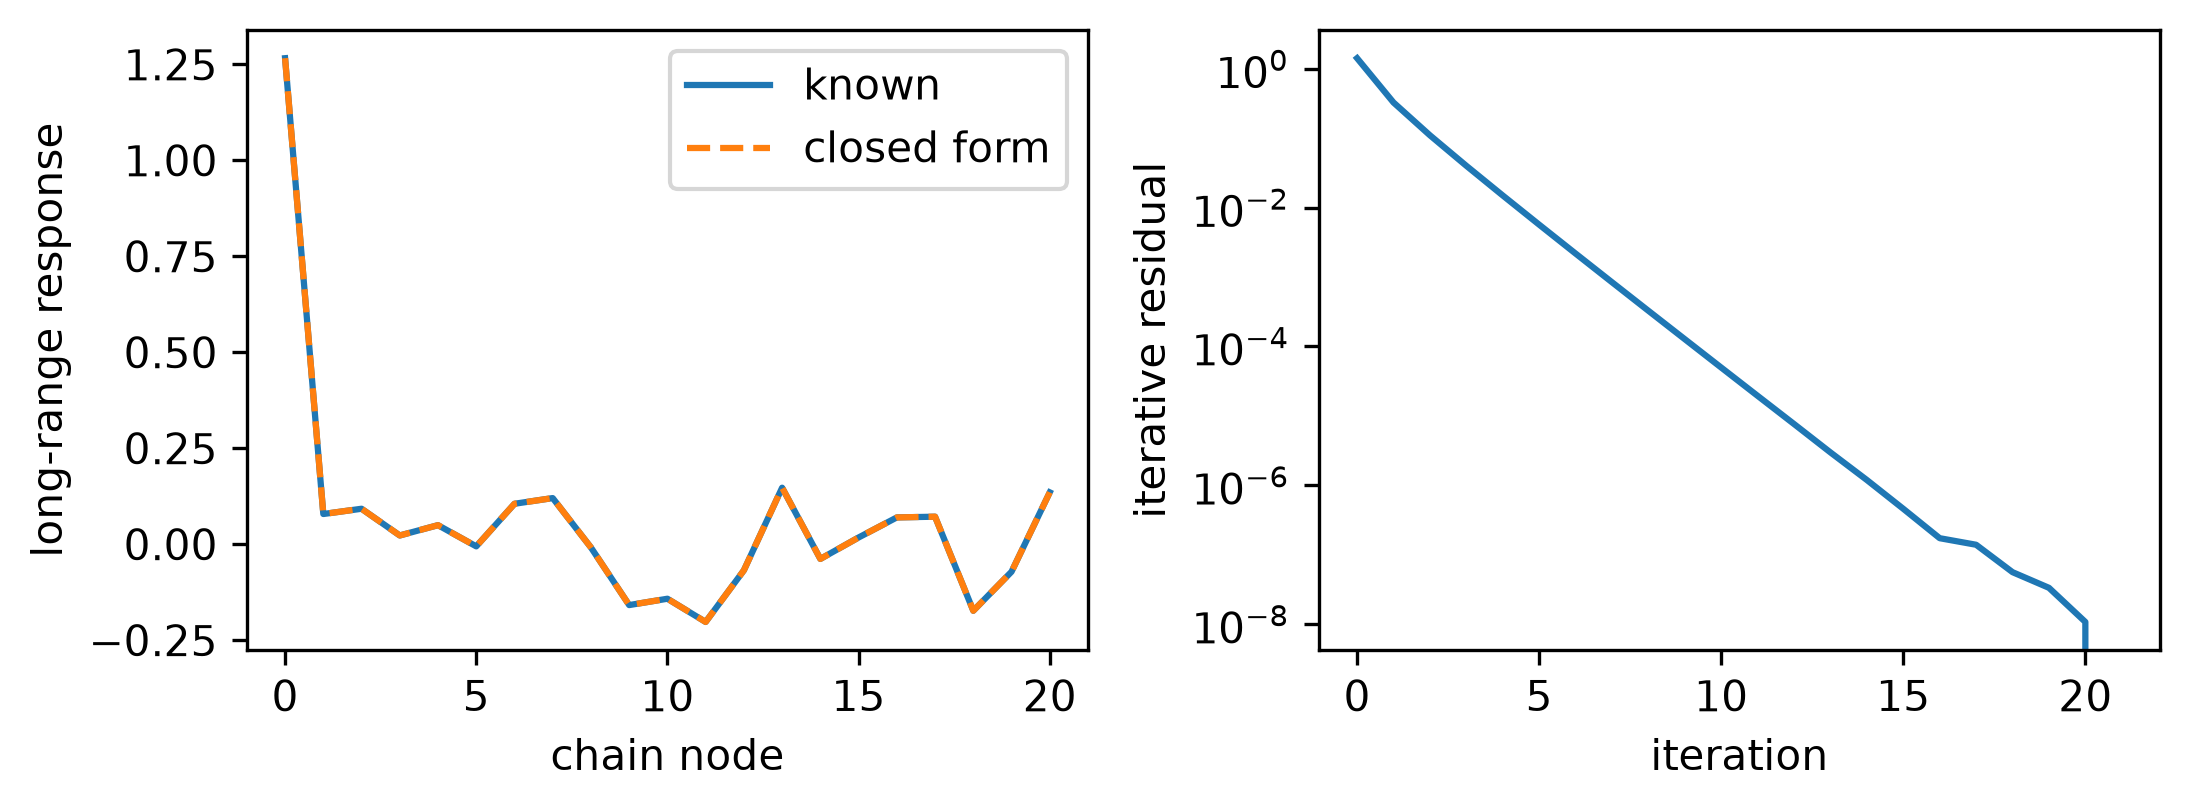

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(7.4, 2.8))
axes[0].plot(data.target[:, 0], label="known")
axes[0].plot(closed.output.detach()[:, 0], "--", label="closed form")
axes[0].set(xlabel="chain node", ylabel="long-range response")
axes[0].legend()
axes[1].semilogy(iterative.solver_result.residuals)
axes[1].set(xlabel="iteration", ylabel="iterative residual")
figure.tight_layout()
plt.show()

## 3. Dense Versus Sparse Route

The dense spectral cache stores an $N$ by $N$ eigenvector matrix. Use it only
when that matrix fits comfortably. Large graphs should retain a sparse graph
operator and select `solve_mode="iterative"`; no dense graph power or spectrum
is then required.

## 4. Cora With Source Masks

The snapshot is a connected, source-indexed induced subgraph of Cora [[82]](https://jseluis.github.io/silva-networks/paper/references/#ref-82). It
retains train, validation, and test node identities so the complete tensor path
can be exercised quickly. An induced graph changes the transductive problem;
published EIGNN comparisons [[78]](https://jseluis.github.io/silva-networks/paper/references/#ref-78) must use the full graph and fixed Planetoid
masks, which the same loader returns when `subset_nodes=None`.

In [6]:
from urllib.request import urlretrieve
from silva_networks import load_source_snapshot

snapshot_path = root / "docs/assets/source-data/cora-induced-96.pt"
if not snapshot_path.exists():
    snapshot_path = Path(".silva-source-data") / "cora-induced-96.pt"
    snapshot_path.parent.mkdir(parents=True, exist_ok=True)
    snapshot_url = (
        "https://raw.githubusercontent.com/jseluis/silva-networks/main/"
        "docs/assets/source-data/cora-induced-96.pt"
    )
    urlretrieve(snapshot_url, snapshot_path)

source_sample = load_source_snapshot(snapshot_path)
print("dataset:", source_sample.receipt.dataset)
print("source indices:", source_sample.receipt.selected_indices)
print("content SHA-256:", source_sample.receipt.content_sha256)
print("preprocessing:")
for step in source_sample.receipt.preprocessing:
    print(" -", step)

dataset: Cora
source indices: (18, 590, 2427, 1786, 349, 139, 37, 2145, 2428, 1954, 1512, 103, 1957, 1560, 1441, 2095, 2275, 1623, 1772, 1790, 910, 750, 2272, 133, 1784, 1775, 135, 1956, 1770, 1128, 426, 2045, 1355, 487, 371, 1779, 102, 2256, 1871, 306, 2082, 807, 2271, 476, 1878, 1561, 1700, 112, 1584, 1553, 1415, 2078, 519, 1830, 1783, 239, 1067, 1190, 236, 1768, 109, 1354, 350, 958, 1346, 581, 1651, 2089, 979, 1781, 1785, 1773, 1782, 2144, 387, 2085, 2080, 399, 1802, 1705, 2107, 1798, 1771, 699, 1248, 2079, 1171, 554, 1776, 695, 1072, 1069, 1245, 1855, 1311, 859)
content SHA-256: 6d61add1c8e823e42a5f53f39d6b67aad5bb52a1367b71ed2e4827b6676e4d76
preprocessing:
 - source node features
 - source edges
 - source split masks
 - deterministic connected induced subset; teaching protocol, not source benchmark


In [7]:
from torch.nn import functional as F
from silva_networks import normalized_graph_operator

real_x = source_sample.tensors["x"]
real_edges = source_sample.tensors["edge_index"]
real_y = source_sample.tensors["y"].long()
real_train = source_sample.tensors["train_mask"].bool()
real_validation = source_sample.tensors["validation_mask"].bool()
real_test = source_sample.tensors["test_mask"].bool()
real_operator = normalized_graph_operator(real_edges, real_x.shape[0]).to(real_x)
real_model = SILVAEfficientInfiniteGraphEquilibrium(
    real_x.shape[1],
    16,
    int(real_y.max()) + 1,
    gamma=0.7,
    solve_mode="iterative",
    config=SolverConfig(
        solver="picard", max_iter=80, tol=1e-6, backward_mode="unrolled"
    ),
)
optimizer = torch.optim.Adam(real_model.parameters(), lr=1e-2)
real_losses = []
for _ in range(3):
    optimizer.zero_grad()
    real_result = real_model(real_x, real_operator, return_result=True)
    real_loss = F.cross_entropy(real_result.output[real_train], real_y[real_train])
    real_loss.backward()
    optimizer.step()
    real_losses.append(float(real_loss.detach()))

real_result = real_model(real_x, real_operator, return_result=True)
prediction = real_result.output.argmax(dim=1)
for name, mask in (
    ("train", real_train),
    ("validation", real_validation),
    ("test", real_test),
):
    accuracy = (prediction[mask] == real_y[mask]).float().mean()
    print(name, "nodes", int(mask.sum()), "compact accuracy", float(accuracy))
print("loss trajectory:", real_losses)
print("residual:", real_result.solver_result.residual)

train nodes 9 compact accuracy 1.0
validation nodes 15 compact accuracy 0.6000000238418579
test nodes 41 compact accuracy 0.5853658318519592
loss trajectory: [2.0085103511810303, 1.5095243453979492, 1.005994200706482]
residual: 6.178469220685656e-07


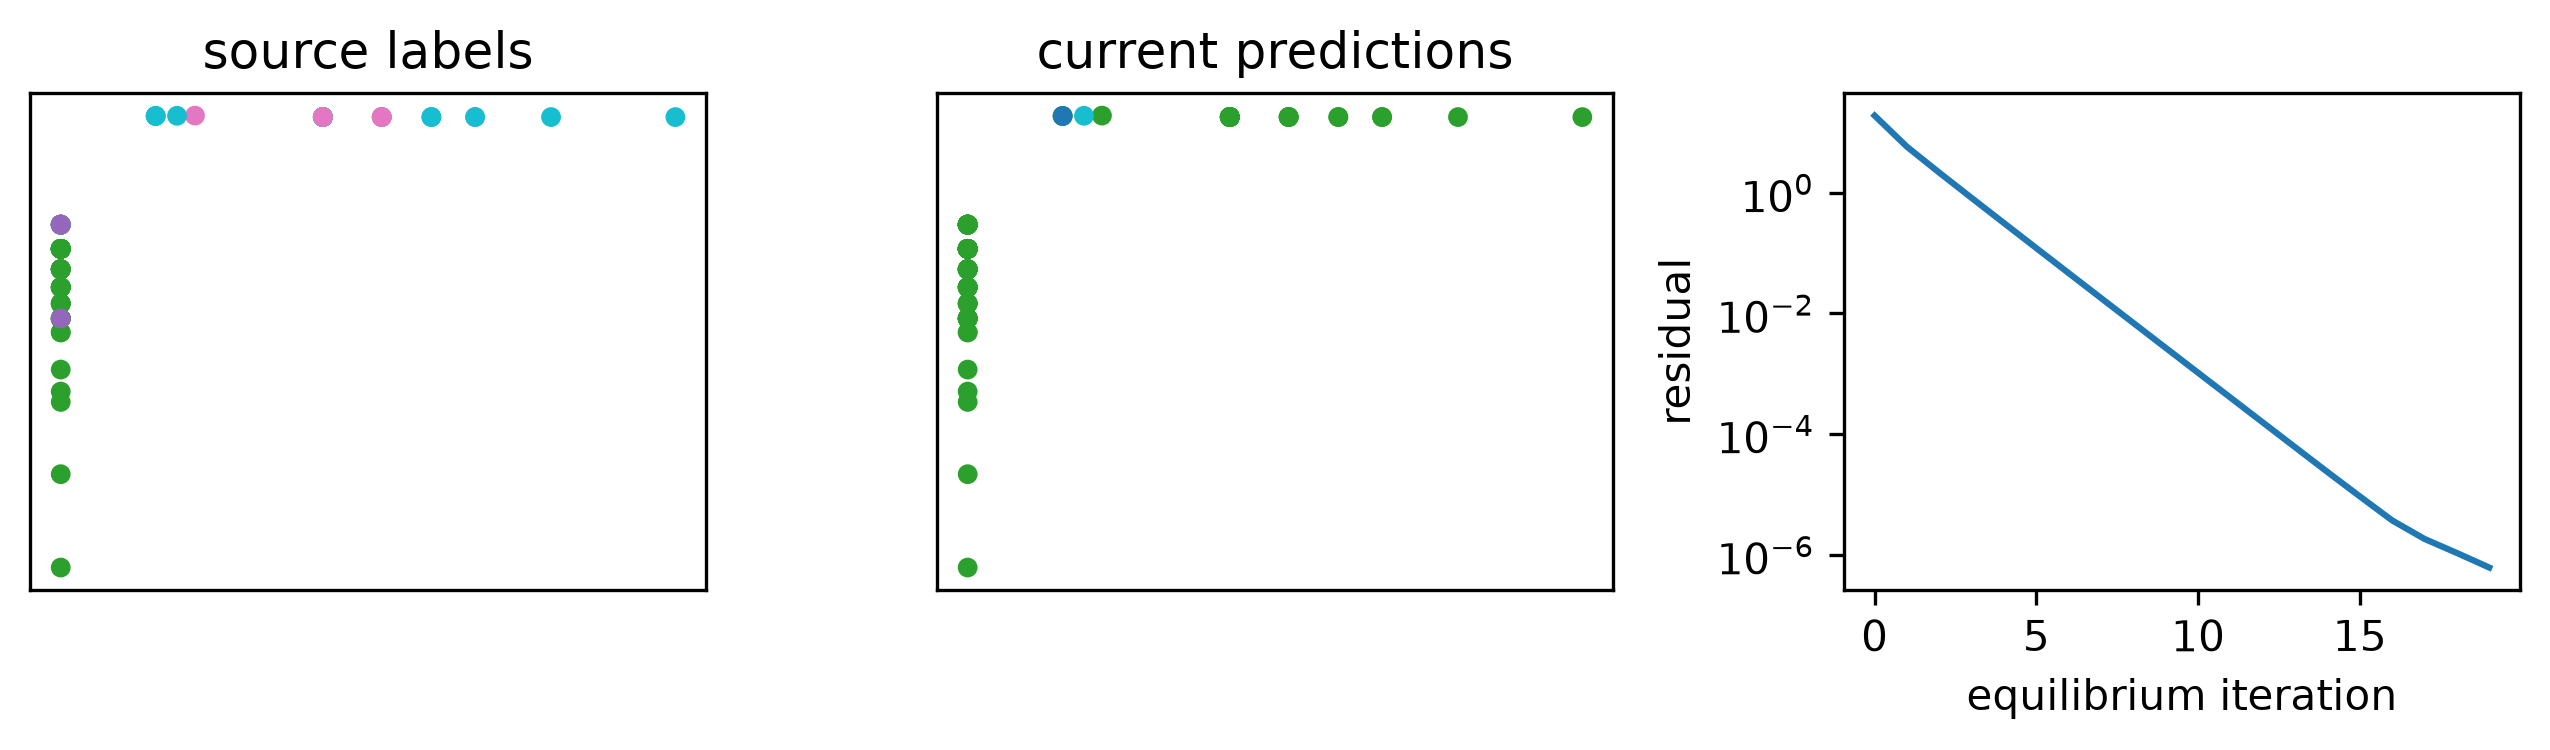

In [8]:
eigenvalues, eigenvectors = torch.linalg.eigh(real_operator)
coordinates = eigenvectors[:, -3:-1].detach()
figure, axes = plt.subplots(1, 3, figsize=(8.6, 2.6))
axes[0].scatter(coordinates[:, 0], coordinates[:, 1], c=real_y, s=14, cmap="tab10")
axes[0].set_title("source labels")
axes[1].scatter(coordinates[:, 0], coordinates[:, 1], c=prediction, s=14, cmap="tab10")
axes[1].set_title("current predictions")
axes[2].semilogy(real_result.solver_result.residuals)
axes[2].set(xlabel="equilibrium iteration", ylabel="residual")
for axis in axes[:2]:
    axis.set(xticks=[], yticks=[])
figure.tight_layout()
plt.show()

## Source-Scale Reproduction Contract

The compact run above verifies the defining mechanism, shapes, diagnostics,
and gradients. A published benchmark requires the source data, preprocessing,
architecture dimensions, optimization schedule, seeds, and evaluation budget.
The executable registry keeps those obligations beside the constructor.

In [9]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec('silva_efficient_infinite_graph')
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("data sources:")
for value in spec.data_sources:
    print(" -", value)
print("source-scale steps:")
for index, value in enumerate(spec.source_scale_steps, start=1):
    print(f" {index}. {value}")
print("metrics:", spec.metrics)
print("preserved mechanisms:", spec.preserved_mechanisms)
print("SILVA extension points:", spec.silva_extensions)
print("benchmark obligations:", spec.benchmark_requirements)
print("constructor:", spec.constructor_signature)

equation: Z_star=gamma S^T Z_star g(F)^T+X; g(F)=F^T F/||F^T F||_F
datasets: ('Cora', 'Citeseer', 'Pubmed', 'Amazon co-purchase graphs', 'compact chain graphs')
data sources:
 - https://arxiv.org/abs/2202.10720
 - https://github.com/liu-jc/EIGNN
source-scale steps:
 1. Acquire a declared graph benchmark and preserve its official features, labels, split, and normalization.
 2. Use the normalized channel Gram map and match gamma, width, optimizer, early stopping, and either spectral or iterative solve route.
 3. Check closed-form/iterative agreement on a compact graph before reporting source-scale node accuracy, denominator margin, runtime, and memory.
metrics: ('node accuracy', 'closed-form/iterative agreement', 'denominator margin', 'runtime and memory')
preserved mechanisms: ('Frobenius-normalized positive-semidefinite channel Gram map', 'graph/channel eigendecomposition for an exact dense symmetric solve', 'the same equilibrium equation through iterative sparse or directed propagatio

## From 39 Silva Efficient Infinite Graph to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one latent vector per node or entity |
| Condition | node features, edges, edge attributes, and graph batches |
| Repeated computation | a source-injected graph message or monotone graph transition |
| Required invariants | node relabeling equivariance, graph boundaries, and state shape |
| Replaceable components | input projection, message field, global field, transition, pooling, and head |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Source, Readout, and Spectral Policy

```python
model = SILVAEfficientInfiniteGraphEquilibrium(
    in_dim=input_dim,
    state_dim=state_dim,
    out_dim=classes,
    gamma=gamma,
    source=my_feature_transform,
    readout=my_node_head,
    solve_mode="auto",
)
spectrum = model.precompute_spectrum(normalized_graph)
result = model(features, normalized_graph, spectrum=spectrum, return_result=True)
```

Dense symmetric graphs may reuse the eigendecomposition; large, sparse, or
directed graphs use the iterative route. Full experiments must retain the
official split, graph normalization, feature preprocessing, gamma, width,
adversarial or noise protocol, and memory/runtime accounting.


In [10]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**node/graph error, physical graph residual, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **node count, edge count, feature width, and number of graphs**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [11]:
notebook_reproduction_record = {
    "notebook": '39_silva_efficient_infinite_graph.ipynb',
    "state": 'one latent vector per node or entity',
    "condition": 'node features, edges, edge attributes, and graph batches',
    "transition": 'a source-injected graph message or monotone graph transition',
    "invariants": 'node relabeling equivariance, graph boundaries, and state shape',
    "compact_metric": 'node/graph error, physical graph residual, and fixed-point residual',
    "scale_axis": 'node count, edge count, feature width, and number of graphs',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '39_silva_efficient_infinite_graph.ipynb',
 'state': 'one latent vector per node or entity',
 'condition': 'node features, edges, edge attributes, and graph batches',
 'transition': 'a source-injected graph message or monotone graph transition',
 'invariants': 'node relabeling equivariance, graph boundaries, and state shape',
 'compact_metric': 'node/graph error, physical graph residual, and fixed-point residual',
 'scale_axis': 'node count, edge count, feature width, and number of graphs'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **graph propagation factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **one latent vector per node or entity**, and its repeated map,
**a source-injected graph message or monotone graph transition**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [12]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('graph propagation factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


graph propagation factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


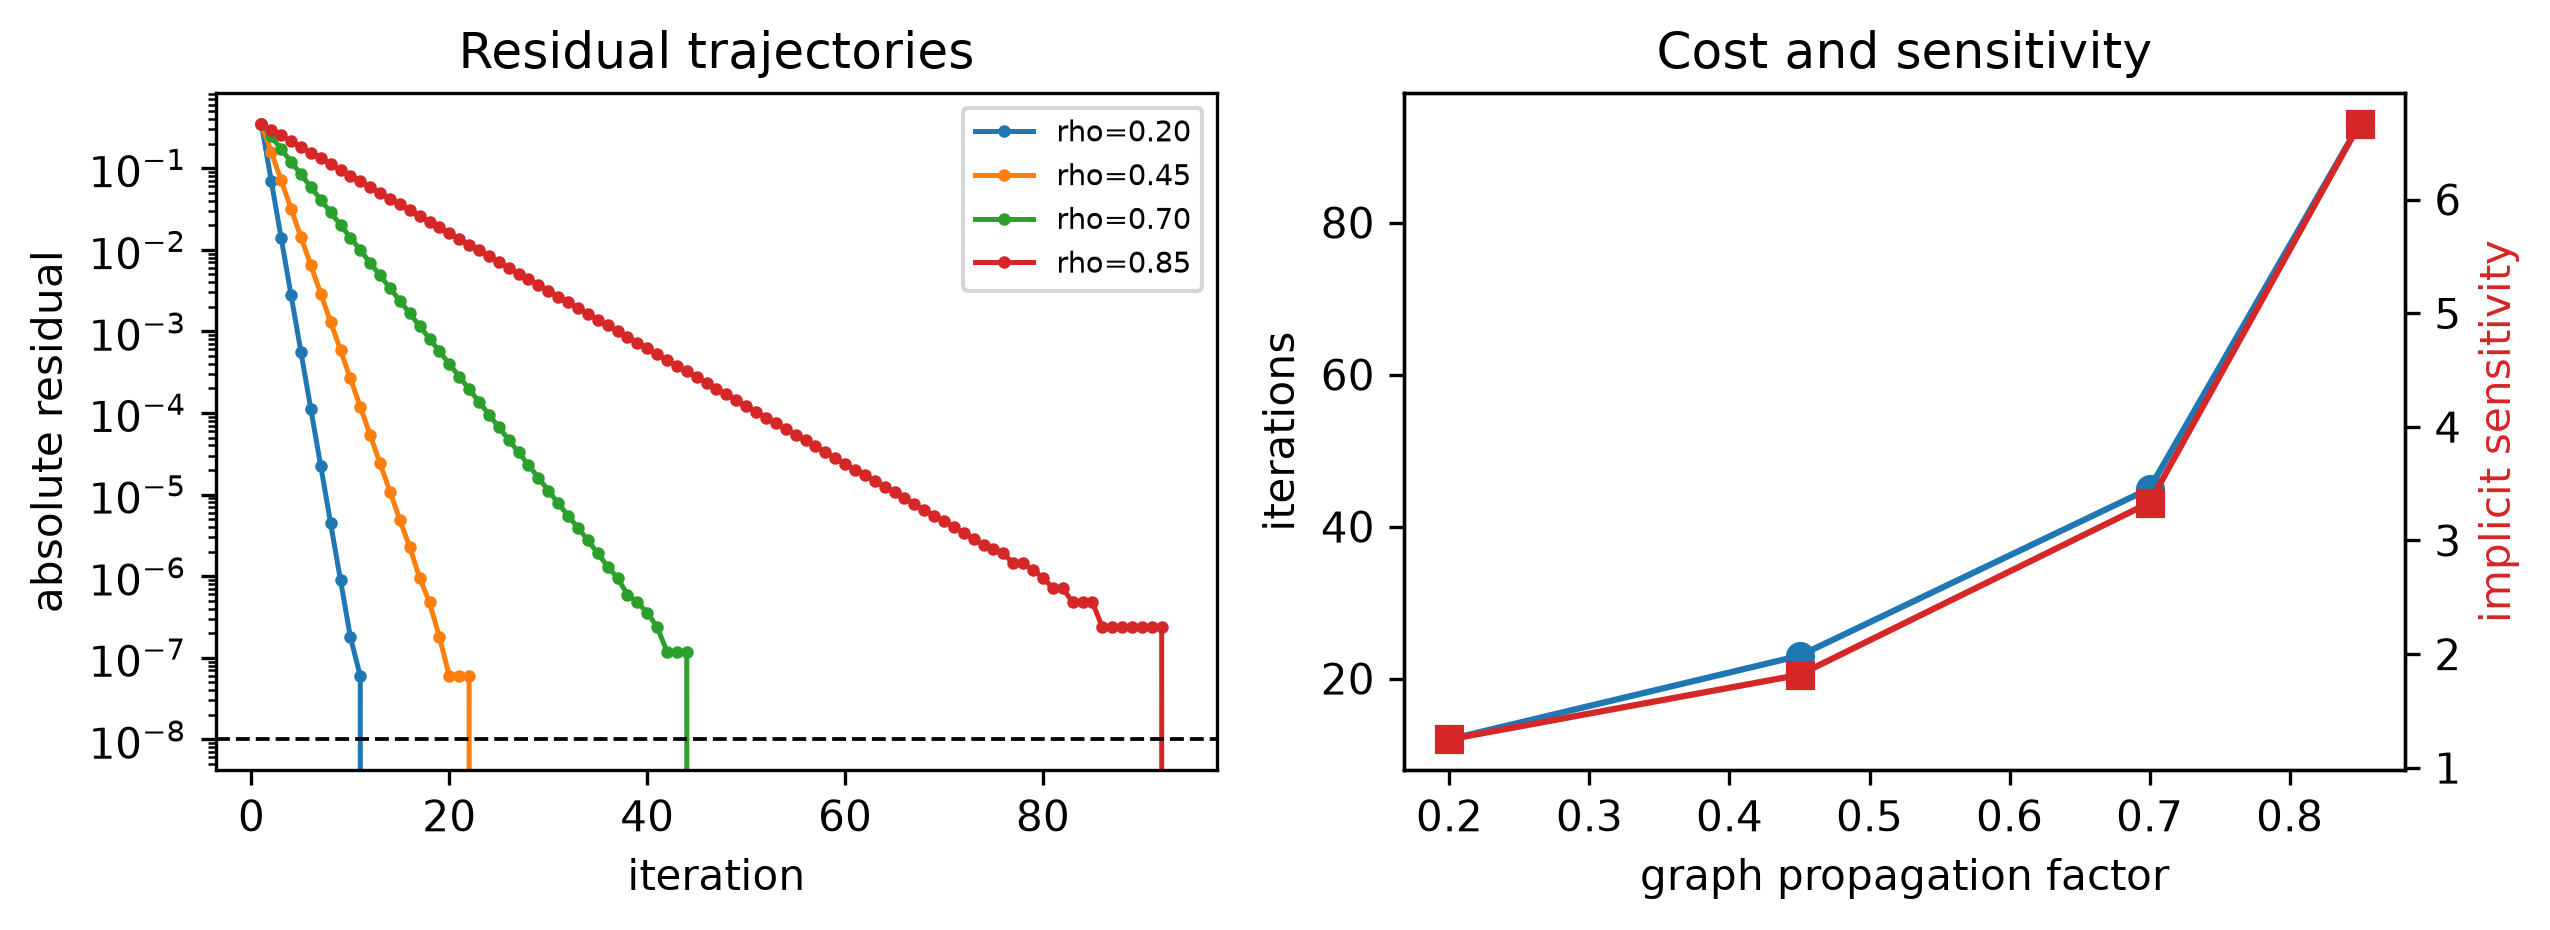

In [13]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('graph propagation factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the graph propagation factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | node/graph error, physical graph residual, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | node relabeling equivariance, graph boundaries, and state shape |
| Scale sweep | Change one of node count, edge count, feature width, and number of graphs at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the spectral closed form derived? | [Structured Equilibrium Families](https://jseluis.github.io/silva-networks/learn/structured-equilibrium-families/#efficient-infinite-depth-graph-equilibrium) |
| Which spectral and iterative graph APIs are public? | [Structured Equilibria API](https://jseluis.github.io/silva-networks/api/structured_equilibria/) |
| How is the exact long-range chain target constructed? | [Structured Data API](https://jseluis.github.io/silva-networks/api/structured_data/) |
